# Case study II — engineering a more thermostable DHFR

**Dihydrofolate reductase (DHFR, the *folA* gene product)** is one of the most-studied enzymes in biology: essential for nucleotide synthesis, the target of the antibiotic trimethoprim and the anticancer drug methotrexate, and a classic model for protein engineering and directed evolution. A recurring goal is a **more thermostable variant** — a more robust biocatalyst that tolerates process conditions without losing activity.

This case runs that protein-engineering campaign end-to-end with `ov.synbio` on the **real *E. coli* DHFR sequence** (UniProt P0ABQ4, 159 aa), using the real SOTA models throughout: *confirm function* → *fold it* → *map the fitness & stability landscapes* → *design stabilised variants* → *the DNA to build them*.

Runs on a GPU (ESMFold / ESM / ProteinMPNN / ThermoMPNN). `pip install 'omicverse[synbio]'`.

In [1]:
import omicverse as ov
ov.plot_set()
# the real E. coli DHFR (folA) sequence, UniProt P0ABQ4
DHFR = ('MISLIAALAVDRVIGMENAMPWNLPADLAWFKRNTLNKPVIMGRHTWESIGRPLPGRKNIILSSQPGTDDRVTWVKSVDE'
        'AIAACGDVPEIMVIGGGRVYEQFLPKAQKLYLTHIDAEVEGDTHFPDYEPDDWESVFSEFHDADAQNSHSYCFEILERR')
print('DHFR length:', len(DHFR), 'aa')

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


🔬 Starting plot initialization...
🧬 Detecting GPU devices…


✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

DHFR length: 159 aa


## 1 — Confirm the enzyme's function (CLEAN)

Before engineering, verify what we have. `enzyme_function(method='clean')` runs the real trained CLEAN model against ~5,200 SwissProt EC cluster centres — it should return DHFR's EC number, **1.5.1.3**.

CLEAN EC prediction: [('1.5.1.3', 0.9937)]   (DHFR = EC 1.5.1.3)


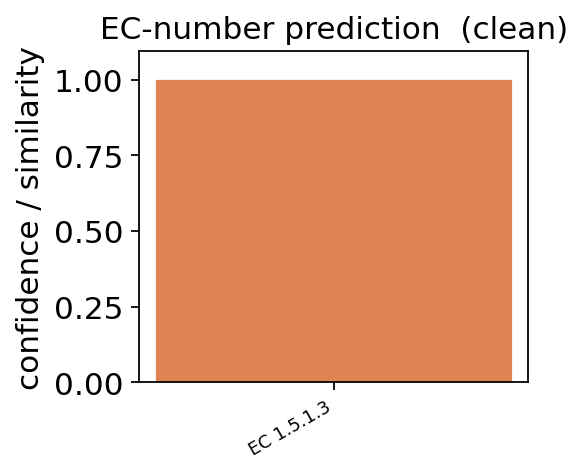

In [2]:
ec = ov.synbio.enzyme_function(DHFR, method='clean', verbose=False)
print('CLEAN EC prediction:', ec.predictions[:2], '  (DHFR = EC 1.5.1.3)')
ov.synbio.plot_ec_prediction(ec)
None

## 2 — Fold it with ESMFold

`predict_structure` folds the sequence with ESMFold (no MSA). DHFR is a well-folded α/β enzyme, so mean pLDDT is high. We keep the PDB for the stability step and view it in interactive 3D.

In [3]:
pred = ov.synbio.predict_structure(DHFR, out_path='dhfr.pdb')
print('mean pLDDT =', round(pred.mean_plddt, 1), '| device =', pred.device)
ov.synbio.view_structure(pred)

[ov.synbio.predict_structure] device=cuda (NVIDIA H100 80GB HBM3, 79 GB) len=159


Some weights of EsmForProteinFolding were not initialized from the model checkpoint at facebook/esmfold_v1 and are newly initialized: ['esm.contact_head.regression.bias', 'esm.contact_head.regression.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[ov.synbio.predict_structure] done: mean pLDDT=94.3
mean pLDDT = 94.3 | device = cuda


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 3 — Fitness landscape: which positions tolerate change? (ESM-1v)

`variant_effect` runs a zero-shot saturation scan with ESM-1v. The heatmap shows conserved (blue) positions — likely catalytic / structural, *don't* touch — versus tolerant (red) positions where mutations are candidates. This is the *in-silico* deep-mutational-scan that guides where to engineer.

[ov.synbio.variant_effect] model=esm1v scoring=masked-marginals device=cuda (NVIDIA H100 80GB HBM3, 79 GB)


scored 3021 substitutions; most-tolerated: N34L


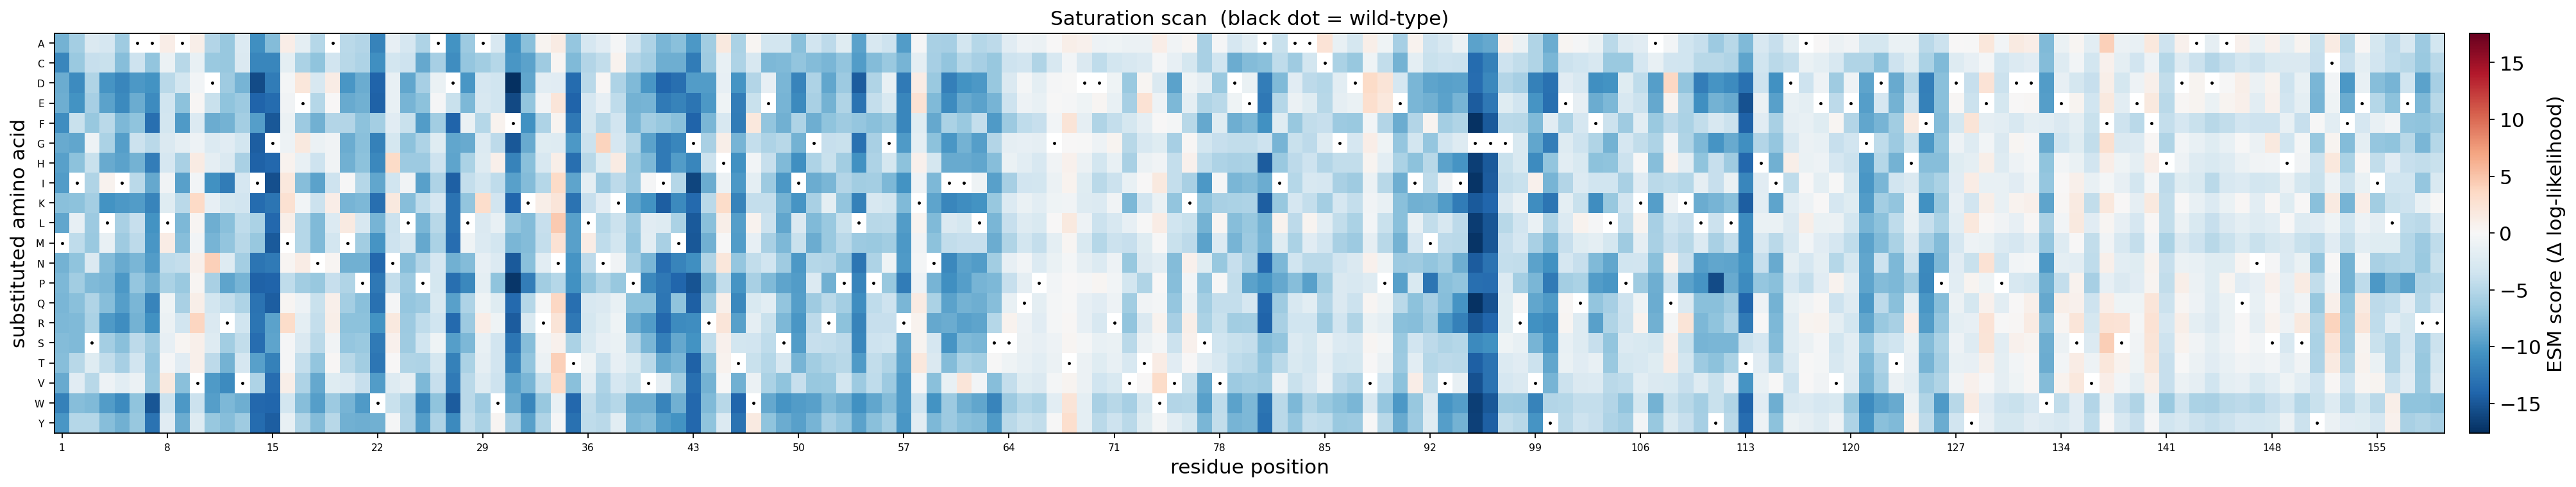

In [4]:
dms = ov.synbio.variant_effect(DHFR, model='esm1v')
print('scored', len(dms), 'substitutions; most-tolerated:', dms.iloc[0]['mutation'])
ov.synbio.plot_variant_effect(dms)
None

## 4 — Stability landscape: find thermostabilising mutations (ThermoMPNN)

For thermostability specifically, `stability_ddg(method='thermompnn')` runs the real trained ThermoMPNN model on the folded structure — calibrated ΔΔG in kcal/mol for every point mutation. **Negative ΔΔG = stabilising.** These are the mutations that make DHFR more robust; we rank them.

[ov.synbio.stability_ddg] pdb=dhfr.pdb method=thermompnn device=cuda (NVIDIA H100 80GB HBM3, 79 GB)


top predicted thermostabilising single mutations (ΔΔG kcal/mol):
mutation       ddg
   S135I -1.237436
   S135V -1.111658
    K32W -1.016983
    K32C -0.939094
   E154I -0.879996
   E154V -0.876792
    K32Y -0.861735
   T123I -0.827052


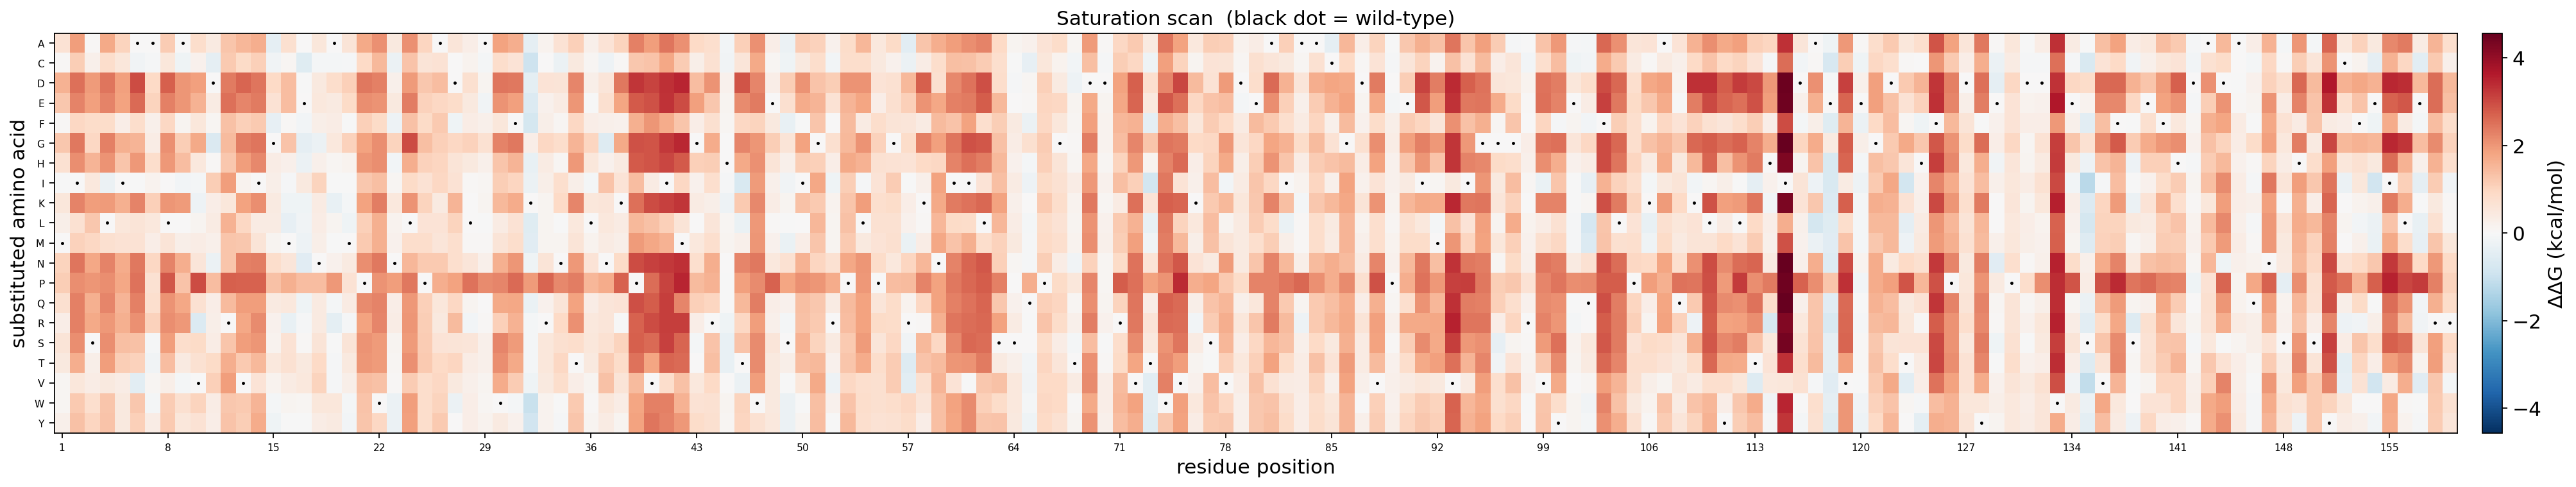

In [5]:
ddg = ov.synbio.stability_ddg('dhfr.pdb', method='thermompnn')
stabilising = ddg.sort_values('ddg').head(8)      # most negative = most stabilising
print('top predicted thermostabilising single mutations (ΔΔG kcal/mol):')
print(stabilising[['mutation', 'ddg']].to_string(index=False))
ov.synbio.plot_variant_effect(ddg)
None

## 5 — Design a stabilised variant

Combine the top stabilising mutations (ThermoMPNN) — keeping only those the ESM fitness landscape also tolerates, to avoid wrecking activity — into a candidate multi-mutant. We accept a mutation only if it is stabilising **and** its ESM variant-effect score isn't strongly negative.

In [6]:
esm = dms.set_index('mutation')['score'].to_dict()
picked, used_pos, seq = [], set(), list(DHFR)
for _, r in ddg.sort_values('ddg').iterrows():        # most stabilising first
    if r['ddg'] >= 0:                                 # keep only stabilising (ddG < 0)
        break
    if r['pos'] in used_pos or esm.get(r['mutation'], 0) < -2.5:   # 1/position, skip ESM-disfavoured
        continue
    picked.append(r['mutation']); used_pos.add(r['pos']); seq[int(r['pos']) - 1] = r['mut']
    if len(picked) >= 5:
        break
variant = ''.join(seq)
tot = sum(ddg.set_index('mutation').loc[m, 'ddg'] for m in picked)
print('designed stabilising variant:', ' + '.join(picked))
print(f'predicted total ddG: {tot:.2f} kcal/mol  ({len(picked)} mutations, ESM-tolerated)')

designed stabilising variant: S135I + E154I + T73I + A117L + Q102L
predicted total ddG: -4.50 kcal/mol  (5 mutations, ESM-tolerated)


## 6 — Sanity-check the design with ProteinMPNN

Does the folded scaffold still "want" these residues? `inverse_design` (ProteinMPNN) samples sequences for the DHFR backbone; a good stabilising design should not stray far from what the structure prefers (native recovery stays high).

In [7]:
designs = ov.synbio.inverse_design('dhfr.pdb', num_sequences=4)
print('ProteinMPNN native score:', round(designs[0].score, 3),
      '| best resampled design score:', round(designs[1].score, 3))

[ov.synbio.inverse_design] method=proteinmpnn backbone=dhfr.pdb device=cuda (NVIDIA H100 80GB HBM3, 79 GB) n=4


ProteinMPNN native score: 1.395 | best resampled design score: 0.742


## 7 — Build it: codon-optimize the variant + primers

Order the stabilised DHFR variant as a synthetic *E. coli*-optimised gene with cloning primers.

In [8]:
opt = ov.synbio.codon_optimize(variant, host='e_coli')
print(opt)
print('cloning primers:', ov.synbio.design_primers(opt.sequence)[0])

CodonResult(host='e_coli', len=477, edits=118, GC=0.54, constraints_ok=True)
cloning primers: PrimerPair(product=127bp, Tm=60.0/60.0, L=AACACCCTGAACAAACCGGT, R=TCACCCAAATCACGCGATCA)


## Summary

On the real *E. coli* DHFR we ran a complete protein-engineering campaign with the SOTA models: **confirmed** its function (CLEAN → EC 1.5.1.3), **folded** it (ESMFold), mapped the **fitness** landscape (ESM-1v saturation scan) and the **stability** landscape (ThermoMPNN ΔΔG), **designed** a multi-mutant stabilised variant by combining the most stabilising mutations that ESM also tolerates, **sanity-checked** it against the ProteinMPNN sequence preference, and produced the **codon-optimised gene + primers** to build it.

Every model here is the real, published tool — swap `method=`/`model=` to try alternatives, and see [Case I](t_synbio_case01_succinate.ipynb) for the metabolic-engineering counterpart.